In [1]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\Kirti\OneDrive\Desktop\Loan Default Prediction\data\processed\cleaned_loan_data.csv")

In [3]:
df.head(3)

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,male,married,master's,24240.19,2020.02,employed,0.074,743,17173.72,...,36,581.88,b5,7,40833.47,24302.07,1,0,1,1
1,72,female,married,bachelor's,20172.98,1681.08,employed,0.219,531,22663.89,...,60,573.17,f1,5,27968.01,10803.01,1,0,3,1
2,49,female,single,high school,26181.80,2181.82,employed,0.234,779,3631.36,...,60,76.32,b4,2,15502.25,4505.44,0,0,0,1


Adding Feature

In [4]:
if 'loan_amount' in df.columns and 'annual_income' in df.columns:
    df['loan_income_ratio']=df['loan_amount']/(df['annual_income']+1)

Seperating Feature and Target

In [5]:
x=df.drop('loan_paid_back',axis=1)
y=df['loan_paid_back']

In [6]:
num_cols=x.select_dtypes(include=np.number).columns.tolist()
cat_cols=x.select_dtypes(include=object).columns.tolist()
print("Numerical Columns : ",num_cols)
print()
print("Categorical Columns : ",cat_cols)


Numerical Columns :  ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_income_ratio']

Categorical Columns :  ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


Outlier Handing

In [7]:
def cap_outliers(df,cols):
    df=df.copy()
    for col in cols:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR
        df[col]=np.where(df[col]<lower,lower,df[col])
        df[col]=np.where(df[col]>upper,upper,df[col])

        
    return df        

In [8]:
x=x.copy()
x[num_cols]=cap_outliers(x[num_cols],num_cols)

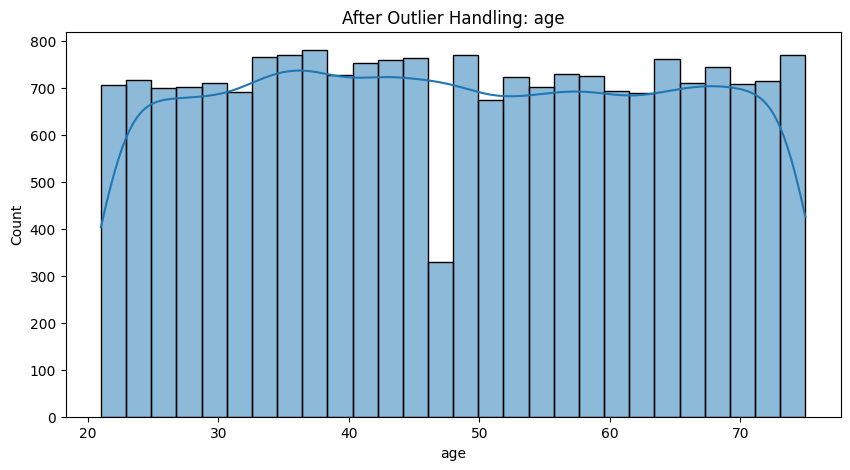

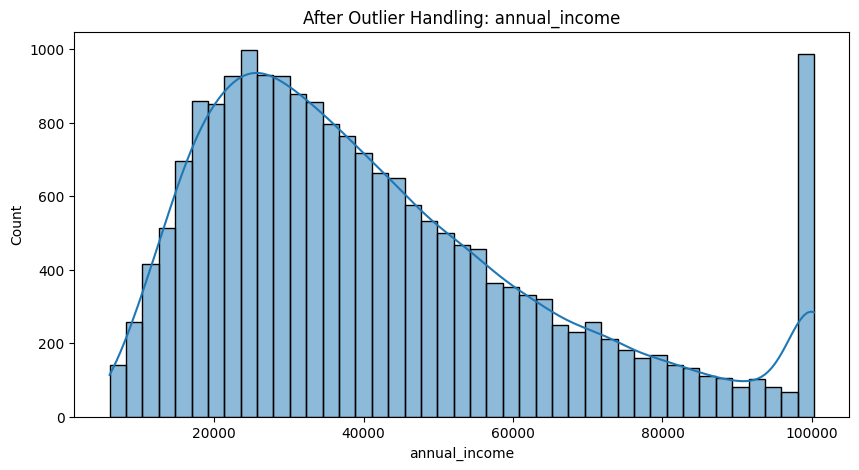

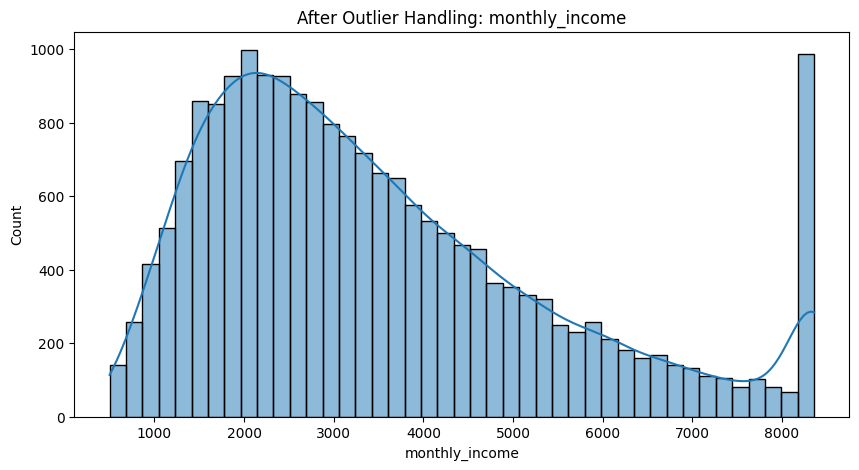

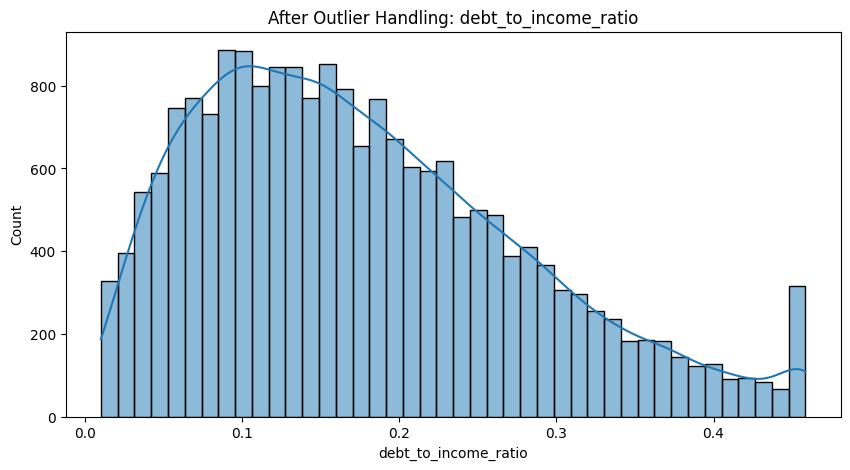

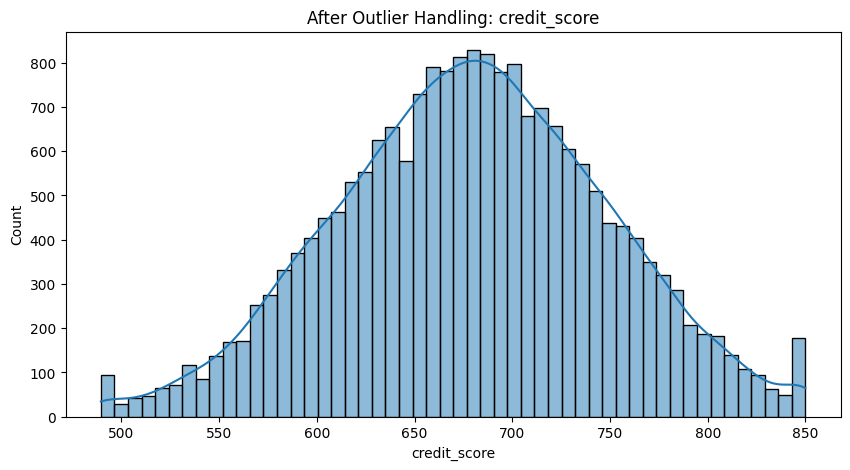

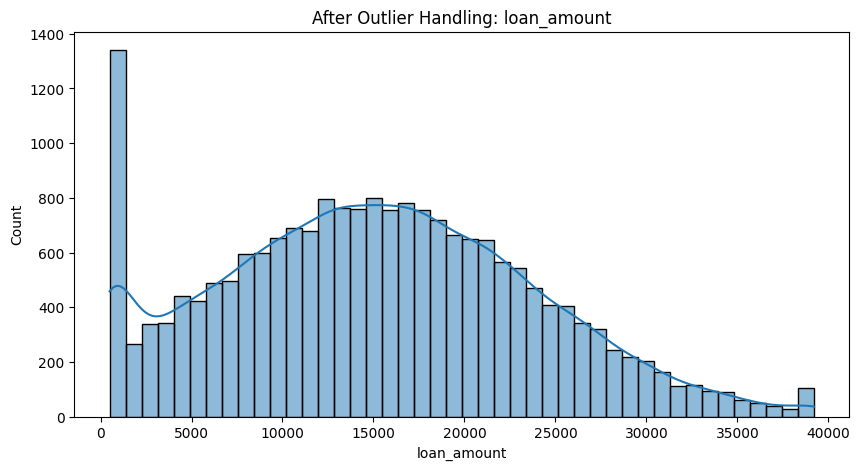

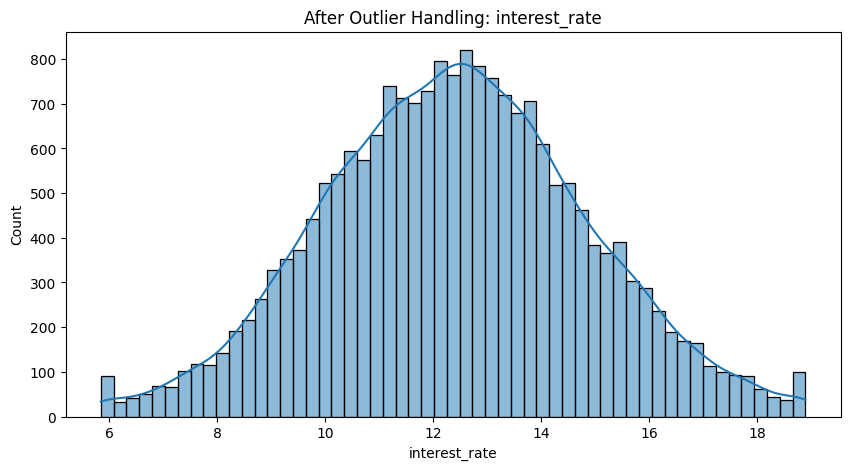

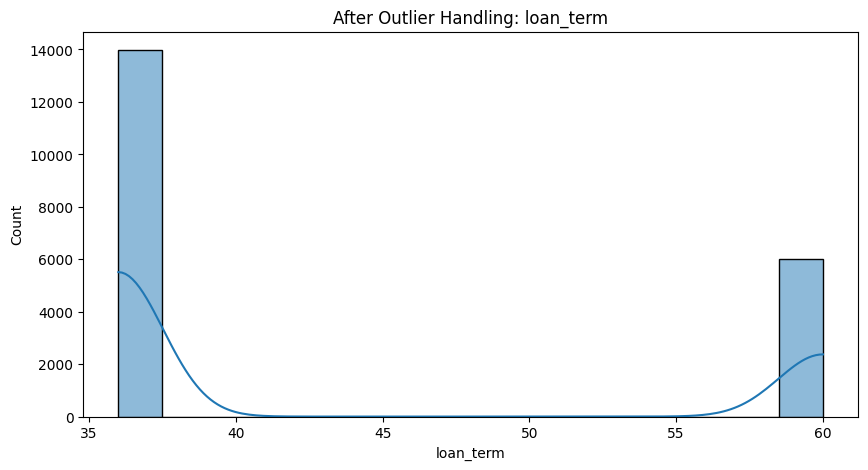

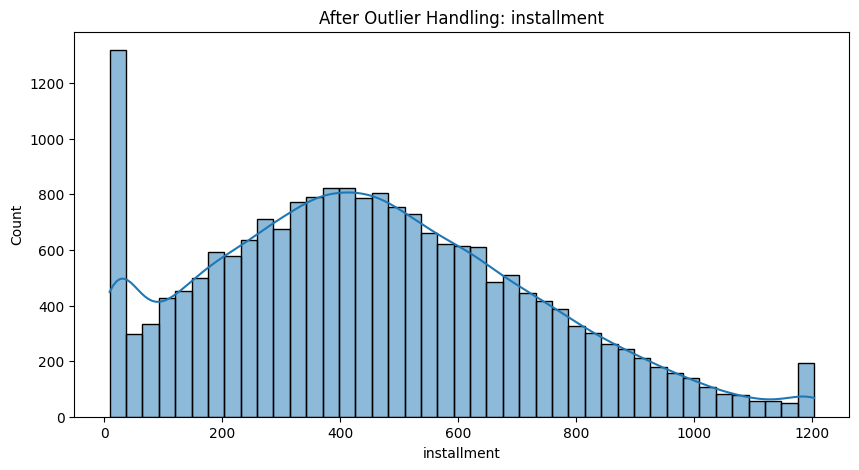

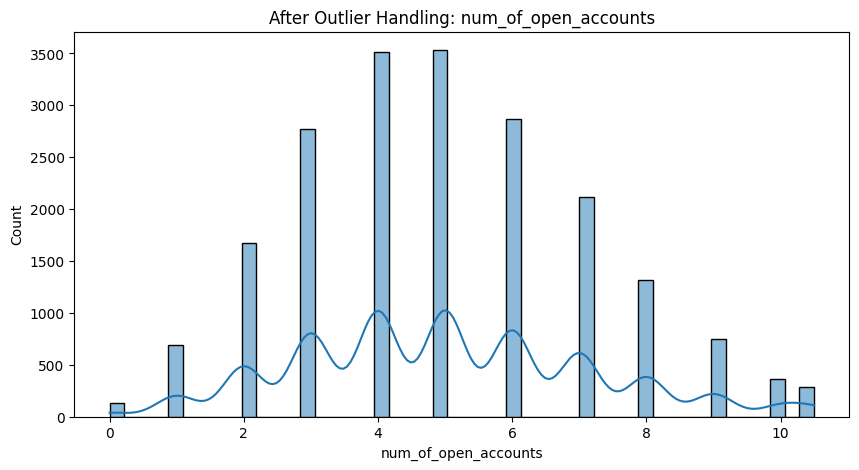

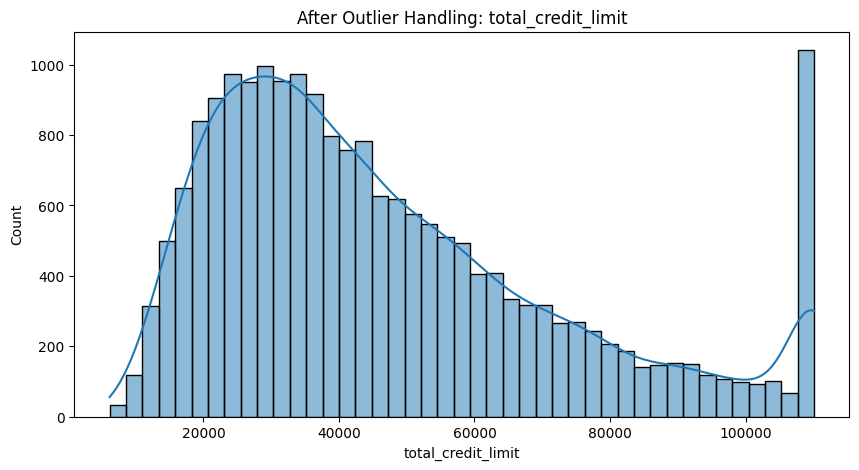

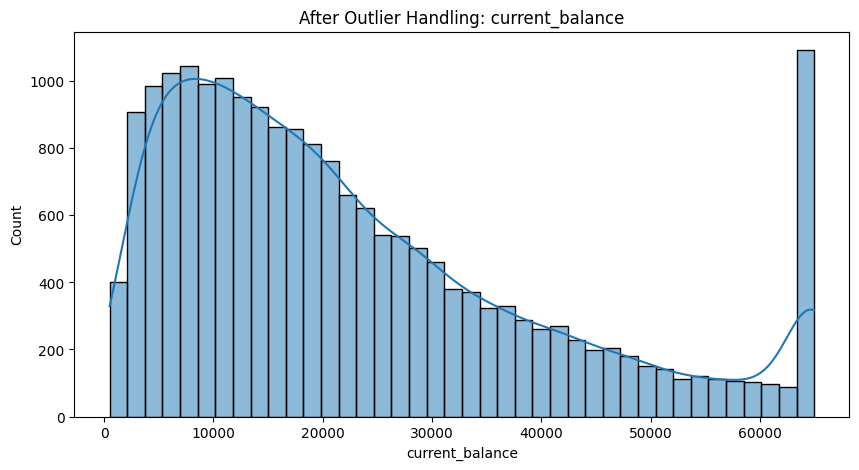

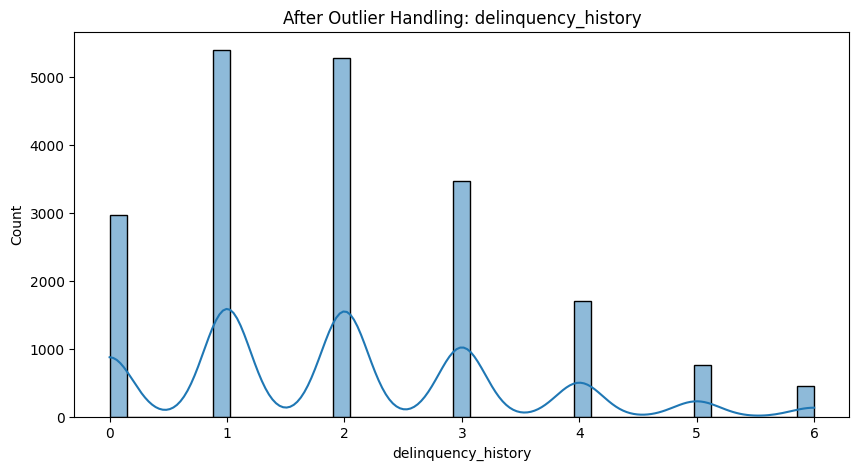

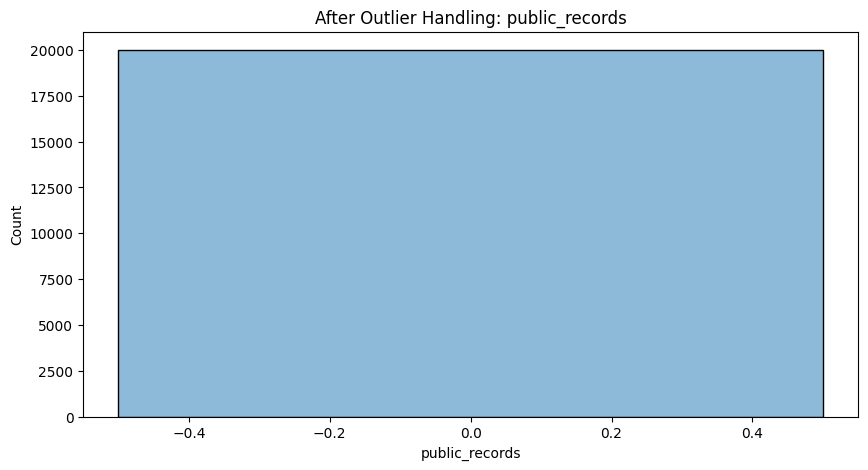

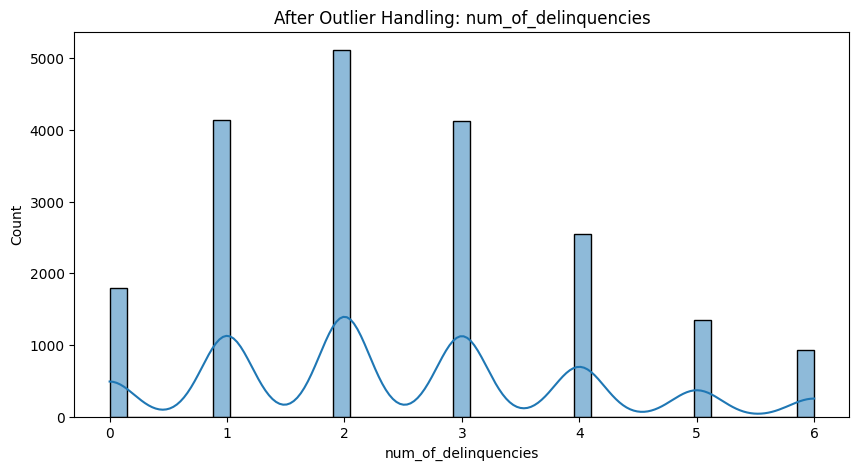

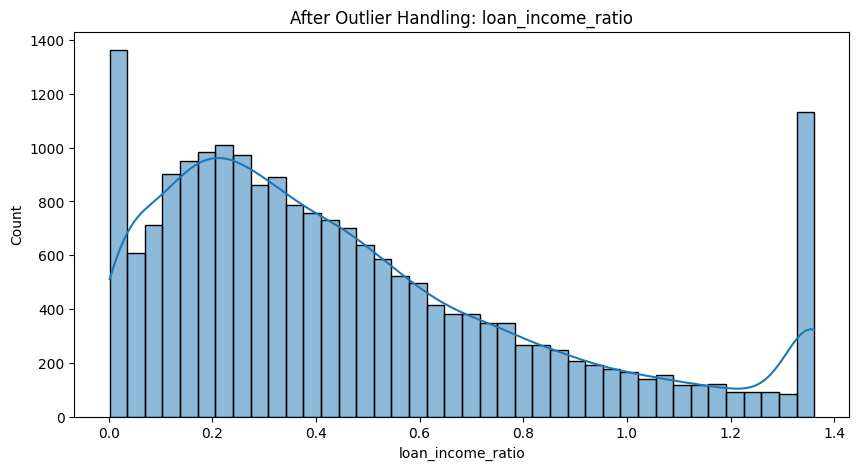

In [9]:
import matplotlib.pyplot as plt 
import seaborn as sns
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(x[col],kde=True)
    plt.title(f"After Outlier Handling: {col}")
    plt.show()

In [10]:
#Converting grade_subgrade to numeric scsorted
def convert_grade(value):
    grade=value[0]
    sub=int(value[1])

    grade_map={'a':1,'b':2,'c':3,'d':4,'e':5,'f':6}
    return grade_map[grade]*10+sub

x['grade_subgrade']=x['grade_subgrade'].apply(convert_grade)

In [11]:
df['education_level'].unique()

array(["master's", "bachelor's", 'high school', 'other', 'phd'],
      dtype=object)

In [12]:
#Ordinal encoding for education_level
from sklearn.preprocessing import OrdinalEncoder
edu_order=["high school","bachelor's","master's","phd","other"]
ordinal_encoder=OrdinalEncoder(categories=[edu_order])
x['education_level']=ordinal_encoder.fit_transform(x[['education_level']])

In [13]:
num_cols=x.select_dtypes(include=np.number).columns.tolist()
cat_cols=x.select_dtypes(include='object').columns.tolist()
print("Numerical : ",num_cols)
print()
print("Categorical : ",cat_cols)


Numerical :  ['age', 'education_level', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_income_ratio']

Categorical :  ['gender', 'marital_status', 'employment_status', 'loan_purpose']


Column Transformation

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(transformers=[('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),cat_cols),
                                           ('num','passthrough',num_cols)])

In [15]:
x_processed=preprocessor.fit_transform(x)

In [16]:
cat_features=preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features=list(cat_features)+num_cols
x_processed=pd.DataFrame(x_processed,columns=all_features)

In [17]:
x_processed.head(3)

,gender_male,gender_other,marital_status_married,marital_status_single,marital_status_widowed,employment_status_retired,employment_status_self-employed,employment_status_student,employment_status_unemployed,loan_purpose_car,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_income_ratio
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,36.0,581.88,25.0,7.0,40833.47,24302.07,1.0,0.0,1.0,0.708452
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.0,573.17,61.0,5.0,27968.01,10803.01,1.0,0.0,3.0,1.123422
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.0,76.32,24.0,2.0,15502.25,4505.44,0.0,0.0,0.0,0.138693


Scaling 

In [18]:
scale_cols = [
    'annual_income','monthly_income','loan_amount',
    'installment','total_credit_limit','current_balance',
    'loan_income_ratio','debt_to_income_ratio'
]

non_scale_cols = [col for col in num_cols if col not in scale_cols]

In [19]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
x_processed[scale_cols]=scaler.fit_transform(x_processed[scale_cols])

In [20]:
x_processed.head(3)

,gender_male,gender_other,marital_status_married,marital_status_single,marital_status_widowed,employment_status_retired,employment_status_self-employed,employment_status_student,employment_status_unemployed,loan_purpose_car,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_income_ratio
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,36.0,0.385280,25.0,7.0,0.017837,0.269405,1.0,0.0,1.0,0.712328
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.0,0.362340,61.0,5.0,-0.369901,-0.340013,1.0,0.0,3.0,1.596235
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.0,-0.946245,24.0,2.0,-0.745594,-0.624318,0.0,0.0,0.0,-0.501290


In [21]:
x_processed.describe()

,gender_male,gender_other,marital_status_married,marital_status_single,marital_status_widowed,employment_status_retired,employment_status_self-employed,employment_status_student,employment_status_unemployed,loan_purpose_car,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_income_ratio
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.00000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.0,20000.00000,2.000000e+04
mean,0.476800,0.021500,0.448700,0.45155,0.028350,0.058800,0.146150,0.039050,0.105650,0.119500,...,43.22280,5.031105e-02,37.395250,4.995675,0.198096,0.208612,1.980000,0.0,2.46185,2.006150e-01
std,0.499474,0.145048,0.497374,0.49766,0.165975,0.235256,0.353265,0.193719,0.307397,0.324384,...,11.00838,7.156126e-01,12.125126,2.198115,0.776880,0.776995,1.440939,0.0,1.55437,7.846051e-01
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,36.00000,-1.122417e+00,11.000000,0.000000,-1.027216,-0.805309,0.000000,0.0,0.00000,-7.924171e-01
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,36.00000,-4.785151e-01,31.000000,3.000000,-0.393635,-0.394658,1.000000,0.0,1.00000,-3.970361e-01
50%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,36.00000,-7.486416e-17,35.000000,5.000000,0.000000,0.000000,2.000000,0.0,2.00000,-5.912121e-17
75%,1.000000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,60.00000,5.214849e-01,44.000000,6.000000,0.606365,0.605342,3.000000,0.0,3.00000,6.029639e-01
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,60.00000,2.021485e+00,65.000000,10.500000,2.106365,2.105342,6.000000,0.0,6.00000,2.102964e+00


In [22]:
x_processed['loan_paid_back']=y.reset_index(drop=True)

In [23]:
x_processed.to_csv(r"C:\Users\Kirti\OneDrive\Desktop\Loan Default Prediction\data\processed\final_processed_data.csv",index=False)